In [1]:
pip install requests beautifulsoup4 pandas

In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://traveltriangle.com/tour-packages/india"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers, timeout=20)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

print("Page Title:", soup.title.get_text(strip=True))

Status Code: 200
Page Title: 3 India Tour Packages - Book India Holiday Packages at Best Prices @ TT


In [6]:
rows = soup.select("div.section-table-row")
print("Rows found:", len(rows))

Rows found: 8


In [7]:
data = []

for row in rows:

    columns = row.select("div.section-table-col")

    if len(columns) >= 4:

        package_name = columns[0].get_text(" ", strip=True)
        duration = columns[1].get_text(" ", strip=True)
        price = columns[2].get_text(" ", strip=True)
        inclusions = columns[3].get_text(" ", strip=True)

        link = columns[0].find("a")

        package_url = ""

        if link and link.get("href"):
            package_url = link["href"]

            if package_url.startswith("/"):
                package_url = "https://traveltriangle.com" + package_url

        data.append({
            "Package_Name": package_name,
            "Duration": duration,
            "Price": price,
            "Inclusions": inclusions,
            "URL": package_url
        })

In [8]:
import pandas as pd
df = pd.DataFrame(data)
print(df.head())
print("\nTotal rows:", len(df))

                                       Package_Name         Duration  \
0        Shimla Manali Tour Packages From Hyderabad         Duration   
1       Most Reasonable Goa Honeymoon Tour Packages  4 Nights/5 Days   
2  Andaman Honeymoon Package - Port Blair, Havelock  4 Nights/5 Days   
3        Romantic Mussoorie Tour Package From Delhi  2 Nights/3 Days   
4             Coorg Package For 2 Nights And 3 Days  2 Nights/3 Days   

         Price                                         Inclusions  \
0       Price*                                         Inclusions   
1   â¹7,999/-  Upto 2 Stars, Meals, Sightseeing, Airport Pick...   
2  â¹15,599/-  Upto 3 Stars, Meals, Sightseeing, Transfers, W...   
3  â¹10,500/-        Upto 3 Stars, Meals, Sightseeing, Transfers   
4  â¹14,500/-  Upto 3 Stars, Meals, Sightseeing, Stay Include...   

                                                 URL  
0                                                     
1  https://traveltriangle.com/packages/4ni

In [9]:
df.to_csv("traveltriangle_raw.csv", index=False)
print("Raw dataset saved successfully!")

Raw dataset saved successfully!


In [13]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://traveltriangle.com/tour-packages/india"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    url,
    headers=headers,
    timeout=20
)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

print("Page Title:", soup.title.get_text(strip=True))

rows = soup.select("div.section-table-row")

print("Rows found:", len(rows))

data = []

for row in rows:

    columns = row.select("div.section-table-col")

    if len(columns) >= 4:

        package_name = columns[0].get_text(" ", strip=True)
        duration = columns[1].get_text(" ", strip=True)
        price = columns[2].get_text(" ", strip=True)
        inclusions = columns[3].get_text(" ", strip=True)

        link = columns[0].find("a")

        package_url = ""

        if link and link.get("href"):
            package_url = link["href"]

            if package_url.startswith("/"):
                package_url = "https://traveltriangle.com" + package_url

        data.append({
            "Package_Name": package_name,
            "Duration": duration,
            "Price": price,
            "Inclusions": inclusions,
            "URL": package_url
        })

df = pd.DataFrame(data)

print("\nFirst 5 records:")
print(df.head())

print("\nTotal records:", len(df))

df.to_csv("traveltriangle_raw.csv", index=False)

print("\nCSV saved successfully!")

Status Code: 200
Page Title: 3 India Tour Packages - Book India Holiday Packages at Best Prices @ TT
Rows found: 8

First 5 records:
                                       Package_Name         Duration  \
0        Shimla Manali Tour Packages From Hyderabad         Duration   
1       Most Reasonable Goa Honeymoon Tour Packages  4 Nights/5 Days   
2  Andaman Honeymoon Package - Port Blair, Havelock  4 Nights/5 Days   
3        Romantic Mussoorie Tour Package From Delhi  2 Nights/3 Days   
4             Coorg Package For 2 Nights And 3 Days  2 Nights/3 Days   

         Price                                         Inclusions  \
0       Price*                                         Inclusions   
1   â¹7,999/-  Upto 2 Stars, Meals, Sightseeing, Airport Pick...   
2  â¹15,599/-  Upto 3 Stars, Meals, Sightseeing, Transfers, W...   
3  â¹10,500/-        Upto 3 Stars, Meals, Sightseeing, Transfers   
4  â¹14,500/-  Upto 3 Stars, Meals, Sightseeing, Stay Include...   

                   

In [14]:
# Remove rows where Package_Name is actually a header
df = df[df["Package_Name"] != "Shimla Manali Tour Packages From Hyderabad"]

# Reset index
df = df.reset_index(drop=True)

print("Records after cleaning:", len(df))

display(df)

Records after cleaning: 7


,Package_Name,Duration,Price,Inclusions,URL
0,Most Reasonable Goa Honeymoon Tour Packages,4 Nights/5 Days,"â¹7,999/-","Upto 2 Stars, Meals, Sightseeing, Airport Pick...",https://traveltriangle.com/packages/4nights-5d...
1,"Andaman Honeymoon Package - Port Blair, Havelock",4 Nights/5 Days,"â¹15,599/-","Upto 3 Stars, Meals, Sightseeing, Transfers, W...",https://traveltriangle.com/packages/4nights-5d...
2,Romantic Mussoorie Tour Package From Delhi,2 Nights/3 Days,"â¹10,500/-","Upto 3 Stars, Meals, Sightseeing, Transfers",https://traveltriangle.com/packages/romantic-2...
3,Coorg Package For 2 Nights And 3 Days,2 Nights/3 Days,"â¹14,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",https://traveltriangle.com/packages/2nights-3d...
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,4 Nights/5 Days,"â¹33,200/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",https://traveltriangle.com/packages/4nights-5d...
5,Mesmerising Manali Trip Package From Chandigarh,2 Nights/3 Days,"â¹9,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",https://traveltriangle.com/packages/2nights-3d...
6,Hills & Houseboat: Munnar and Alleppey Honeymo...,5 Nights/6 Days,"â¹22,000/-","Upto 3 Stars, Meals, Sightseeing, Transfers, H...",https://traveltriangle.com/packages/5N-6D-munn...


In [15]:
import re

def clean_price(price):
    price = str(price)
    
    # Remove everything except numbers
    price = re.sub(r"[^\d]", "", price)
    
    return int(price) if price else None


df["Price_Numeric"] = df["Price"].apply(clean_price)

display(df[["Package_Name", "Price", "Price_Numeric"]])

,Package_Name,Price,Price_Numeric
0,Most Reasonable Goa Honeymoon Tour Packages,"â¹7,999/-",7999
1,"Andaman Honeymoon Package - Port Blair, Havelock","â¹15,599/-",15599
2,Romantic Mussoorie Tour Package From Delhi,"â¹10,500/-",10500
3,Coorg Package For 2 Nights And 3 Days,"â¹14,500/-",14500
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,"â¹33,200/-",33200
5,Mesmerising Manali Trip Package From Chandigarh,"â¹9,500/-",9500
6,Hills & Houseboat: Munnar and Alleppey Honeymo...,"â¹22,000/-",22000


In [16]:
def extract_nights(duration):
    match = re.search(r"(\d+)\s*Nights?", str(duration))
    return int(match.group(1)) if match else None


def extract_days(duration):
    match = re.search(r"(\d+)\s*Days?", str(duration))
    return int(match.group(1)) if match else None


df["Nights"] = df["Duration"].apply(extract_nights)
df["Days"] = df["Duration"].apply(extract_days)

display(df[["Package_Name", "Duration", "Nights", "Days"]])

,Package_Name,Duration,Nights,Days
0,Most Reasonable Goa Honeymoon Tour Packages,4 Nights/5 Days,4,5
1,"Andaman Honeymoon Package - Port Blair, Havelock",4 Nights/5 Days,4,5
2,Romantic Mussoorie Tour Package From Delhi,2 Nights/3 Days,2,3
3,Coorg Package For 2 Nights And 3 Days,2 Nights/3 Days,2,3
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,4 Nights/5 Days,4,5
5,Mesmerising Manali Trip Package From Chandigarh,2 Nights/3 Days,2,3
6,Hills & Houseboat: Munnar and Alleppey Honeymo...,5 Nights/6 Days,5,6


In [17]:
df["Destination"] = "India"

In [18]:
df.to_csv("traveltriangle_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [19]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time

destinations = {
    "India": "https://traveltriangle.com/tour-packages/india",
    "Rajasthan": "https://traveltriangle.com/tour-packages/rajasthan",
    "Kerala": "https://traveltriangle.com/tour-packages/kerala",
    "Himachal": "https://traveltriangle.com/tour-packages/himachal",
    "Andaman": "https://traveltriangle.com/tour-packages/andaman",
    "Sikkim": "https://traveltriangle.com/tour-packages/sikkim",
    "Uttarakhand": "https://traveltriangle.com/tour-packages/uttarakhand"
}

all_data = []

headers = {
    "User-Agent": "Mozilla/5.0"
}

for destination, url in destinations.items():

    print("Scraping:", destination)

    response = requests.get(
        url,
        headers=headers,
        timeout=20
    )

    print("Status:", response.status_code)

    soup = BeautifulSoup(response.text, "html.parser")

    rows = soup.select("div.section-table-row")

    for row in rows:

        columns = row.select("div.section-table-col")

        if len(columns) >= 4:

            package_name = columns[0].get_text(" ", strip=True)
            duration = columns[1].get_text(" ", strip=True)
            price = columns[2].get_text(" ", strip=True)
            inclusions = columns[3].get_text(" ", strip=True)

            link = columns[0].find("a")

            package_url = link.get("href") if link else None

            if package_name and package_name != "Shimla Manali Tour Packages From Hyderabad":

                all_data.append({
                    "Destination": destination,
                    "Package_Name": package_name,
                    "Duration": duration,
                    "Price": price,
                    "Inclusions": inclusions,
                    "URL": package_url
                })

    time.sleep(2)

df_all = pd.DataFrame(all_data)

print("\nTotal records:", len(df_all))

display(df_all.head(10))

Scraping: India
Status: 200
Scraping: Rajasthan
Status: 200
Scraping: Kerala
Status: 200
Scraping: Himachal
Status: 200
Scraping: Andaman
Status: 200
Scraping: Sikkim
Status: 200
Scraping: Uttarakhand
Status: 200

Total records: 47


,Destination,Package_Name,Duration,Price,Inclusions,URL
0,India,Most Reasonable Goa Honeymoon Tour Packages,4 Nights/5 Days,"â¹7,999/-","Upto 2 Stars, Meals, Sightseeing, Airport Pick...",/packages/4nights-5days-goa-honeymoon
1,India,"Andaman Honeymoon Package - Port Blair, Havelock",4 Nights/5 Days,"â¹15,599/-","Upto 3 Stars, Meals, Sightseeing, Transfers, W...",/packages/4nights-5days-andaman-honeymoon
2,India,Romantic Mussoorie Tour Package From Delhi,2 Nights/3 Days,"â¹10,500/-","Upto 3 Stars, Meals, Sightseeing, Transfers",/packages/romantic-2nights-3days-mussoorie-tou...
3,India,Coorg Package For 2 Nights And 3 Days,2 Nights/3 Days,"â¹14,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-coorg-tour
4,India,Best 4N 5D Andaman Sightseeing Tour Package Fo...,4 Nights/5 Days,"â¹33,200/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/4nights-5days-andaman-sightseeing-tour
5,India,Mesmerising Manali Trip Package From Chandigarh,2 Nights/3 Days,"â¹9,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-manali-tour-exhilarating
6,India,Hills & Houseboat: Munnar and Alleppey Honeymo...,5 Nights/6 Days,"â¹22,000/-","Upto 3 Stars, Meals, Sightseeing, Transfers, H...",/packages/5N-6D-munnar-thekkady-alleppey-honey...
7,Rajasthan,Rajasthan Tour Packages,Duration,Price*,Inclusions,None
8,Rajasthan,Discover Our Ravishing 3 Nights 4 Days Rajasth...,3 Nights/4 Days,"â¹9,999/-","Upto 3 Stars, Meals, Sightseeing, Safari, Tran...",/packages/3nights-4days-rajasthan-vacation
9,Rajasthan,Best-Selling 7 Days Rajasthan Tour Packages Fo...,6 Nights/7 Days,"â¹25,000/-","Upto 3 Stars, Meals, Sightseeing, Airport Pick...",/packages/6nights-7days-rajasthan-tour


In [20]:
print(df_all["Destination"].value_counts())

Destination
Rajasthan      8
Himachal       8
Andaman        8
Sikkim         8
Uttarakhand    8
India          7
Name: count, dtype: int64


In [21]:
display(df_all.head(10))

,Destination,Package_Name,Duration,Price,Inclusions,URL
0,India,Most Reasonable Goa Honeymoon Tour Packages,4 Nights/5 Days,"â¹7,999/-","Upto 2 Stars, Meals, Sightseeing, Airport Pick...",/packages/4nights-5days-goa-honeymoon
1,India,"Andaman Honeymoon Package - Port Blair, Havelock",4 Nights/5 Days,"â¹15,599/-","Upto 3 Stars, Meals, Sightseeing, Transfers, W...",/packages/4nights-5days-andaman-honeymoon
2,India,Romantic Mussoorie Tour Package From Delhi,2 Nights/3 Days,"â¹10,500/-","Upto 3 Stars, Meals, Sightseeing, Transfers",/packages/romantic-2nights-3days-mussoorie-tou...
3,India,Coorg Package For 2 Nights And 3 Days,2 Nights/3 Days,"â¹14,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-coorg-tour
4,India,Best 4N 5D Andaman Sightseeing Tour Package Fo...,4 Nights/5 Days,"â¹33,200/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/4nights-5days-andaman-sightseeing-tour
5,India,Mesmerising Manali Trip Package From Chandigarh,2 Nights/3 Days,"â¹9,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-manali-tour-exhilarating
6,India,Hills & Houseboat: Munnar and Alleppey Honeymo...,5 Nights/6 Days,"â¹22,000/-","Upto 3 Stars, Meals, Sightseeing, Transfers, H...",/packages/5N-6D-munnar-thekkady-alleppey-honey...
7,Rajasthan,Rajasthan Tour Packages,Duration,Price*,Inclusions,None
8,Rajasthan,Discover Our Ravishing 3 Nights 4 Days Rajasth...,3 Nights/4 Days,"â¹9,999/-","Upto 3 Stars, Meals, Sightseeing, Safari, Tran...",/packages/3nights-4days-rajasthan-vacation
9,Rajasthan,Best-Selling 7 Days Rajasthan Tour Packages Fo...,6 Nights/7 Days,"â¹25,000/-","Upto 3 Stars, Meals, Sightseeing, Airport Pick...",/packages/6nights-7days-rajasthan-tour


In [22]:
def clean_price(price):
    price = str(price)
    price = re.sub(r"[^\d]", "", price)
    return int(price) if price else None

df_all["Price_Numeric"] = df_all["Price"].apply(clean_price)

In [23]:
def extract_nights(duration):
    match = re.search(r"(\d+)\s*Nights?", str(duration))
    return int(match.group(1)) if match else None


def extract_days(duration):
    match = re.search(r"(\d+)\s*Days?", str(duration))
    return int(match.group(1)) if match else None


df_all["Nights"] = df_all["Duration"].apply(extract_nights)
df_all["Days"] = df_all["Duration"].apply(extract_days)

In [24]:
df_all = df_all.drop_duplicates(
    subset=["Destination", "Package_Name"]
).reset_index(drop=True)

print("Records after removing duplicates:", len(df_all))

Records after removing duplicates: 47


In [25]:
df_all.to_csv(
    "traveltriangle_final_dataset.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [26]:
df_all["Destination"].value_counts()

Destination
Rajasthan      8
Himachal       8
Andaman        8
Sikkim         8
Uttarakhand    8
India          7
Name: count, dtype: int64

In [27]:
# Check dataset information

print("Rows and columns:", df_all.shape)

print("\nColumn names:")
print(df_all.columns.tolist())

print("\nMissing values:")
print(df_all.isnull().sum())

print("\nDuplicate rows:")
print(df_all.duplicated().sum())

Rows and columns: (47, 9)

Column names:
['Destination', 'Package_Name', 'Duration', 'Price', 'Inclusions', 'URL', 'Price_Numeric', 'Nights', 'Days']

Missing values:
Destination      0
Package_Name     0
Duration         0
Price            0
Inclusions       0
URL              5
Price_Numeric    5
Nights           5
Days             5
dtype: int64

Duplicate rows:
0


In [28]:
display(df_all)

,Destination,Package_Name,Duration,Price,Inclusions,URL,Price_Numeric,Nights,Days
0,India,Most Reasonable Goa Honeymoon Tour Packages,4 Nights/5 Days,"â¹7,999/-","Upto 2 Stars, Meals, Sightseeing, Airport Pick...",/packages/4nights-5days-goa-honeymoon,7999.0,4.0,5.0
1,India,"Andaman Honeymoon Package - Port Blair, Havelock",4 Nights/5 Days,"â¹15,599/-","Upto 3 Stars, Meals, Sightseeing, Transfers, W...",/packages/4nights-5days-andaman-honeymoon,15599.0,4.0,5.0
2,India,Romantic Mussoorie Tour Package From Delhi,2 Nights/3 Days,"â¹10,500/-","Upto 3 Stars, Meals, Sightseeing, Transfers",/packages/romantic-2nights-3days-mussoorie-tou...,10500.0,2.0,3.0
3,India,Coorg Package For 2 Nights And 3 Days,2 Nights/3 Days,"â¹14,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-coorg-tour,14500.0,2.0,3.0
4,India,Best 4N 5D Andaman Sightseeing Tour Package Fo...,4 Nights/5 Days,"â¹33,200/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/4nights-5days-andaman-sightseeing-tour,33200.0,4.0,5.0
5,India,Mesmerising Manali Trip Package From Chandigarh,2 Nights/3 Days,"â¹9,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-manali-tour-exhilarating,9500.0,2.0,3.0
6,India,Hills & Houseboat: Munnar and Alleppey Honeymo...,5 Nights/6 Days,"â¹22,000/-","Upto 3 Stars, Meals, Sightseeing, Transfers, H...",/packages/5N-6D-munnar-thekkady-alleppey-honey...,22000.0,5.0,6.0
7,Rajasthan,Rajasthan Tour Packages,Duration,Price*,Inclusions,None,NaN,NaN,NaN
8,Rajasthan,Discover Our Ravishing 3 Nights 4 Days Rajasth...,3 Nights/4 Days,"â¹9,999/-","Upto 3 Stars, Meals, Sightseeing, Safari, Tran...",/packages/3nights-4days-rajasthan-vacation,9999.0,3.0,4.0
9,Rajasthan,Best-Selling 7 Days Rajasthan Tour Packages Fo...,6 Nights/7 Days,"â¹25,000/-","Upto 3 Stars, Meals, Sightseeing, Airport Pick...",/packages/6nights-7days-rajasthan-tour,25000.0,6.0,7.0


In [29]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Destination    47 non-null     object 
 1   Package_Name   47 non-null     object 
 2   Duration       47 non-null     object 
 3   Price          47 non-null     object 
 4   Inclusions     47 non-null     object 
 5   URL            42 non-null     object 
 6   Price_Numeric  42 non-null     float64
 7   Nights         42 non-null     float64
 8   Days           42 non-null     float64
dtypes: float64(3), object(6)
memory usage: 3.4+ KB


In [30]:
print("Minimum price:", df_all["Price_Numeric"].min())
print("Maximum price:", df_all["Price_Numeric"].max())
print("Average price:", df_all["Price_Numeric"].mean())

Minimum price: 2500.0
Maximum price: 38500.0
Average price: 18877.95238095238


In [31]:
destination_summary = df_all.groupby("Destination").agg(
    Package_Count=("Package_Name", "count"),
    Average_Price=("Price_Numeric", "mean"),
    Minimum_Price=("Price_Numeric", "min"),
    Maximum_Price=("Price_Numeric", "max"),
    Average_Days=("Days", "mean")
).round(2)

display(destination_summary)

,Package_Count,Average_Price,Minimum_Price,Maximum_Price,Average_Days
Destination,,,,,
Andaman,8,21989.14,14265.0,30240.0,5.71
Himachal,8,21100.00,8500.0,38500.0,6.57
India,7,16185.43,7999.0,33200.0,4.29
Rajasthan,8,18428.00,3999.0,37999.0,5.57
Sikkim,8,25461.57,15000.0,35500.0,5.43
Uttarakhand,8,10103.57,2500.0,25000.0,3.57


In [32]:
df_all.to_csv(
    "traveltriangle_final_dataset.csv",
    index=False
)

print("✅ Final cleaned dataset saved!")

✅ Final cleaned dataset saved!


In [33]:
# STEP 8: Data Quality Check

print("===== MISSING VALUES =====")
print(df_all.isnull().sum())

print("\n===== DUPLICATE ROWS =====")
print("Number of duplicate rows:", df_all.duplicated().sum())

print("\n===== DATASET SHAPE =====")
print("Rows:", df_all.shape[0])
print("Columns:", df_all.shape[1])

===== MISSING VALUES =====
Destination      0
Package_Name     0
Duration         0
Price            0
Inclusions       0
URL              5
Price_Numeric    5
Nights           5
Days             5
dtype: int64

===== DUPLICATE ROWS =====
Number of duplicate rows: 0

===== DATASET SHAPE =====
Rows: 47
Columns: 9


In [34]:
# Fix missing derived values

import re
import pandas as pd

# Fix URL
df_all["URL"] = df_all["URL"].fillna("Not Available")

# Recreate Price_Numeric from Price
def extract_price(price):
    if pd.isna(price):
        return None
    
    numbers = re.findall(r'[\d,]+', str(price))
    
    if numbers:
        return float(numbers[0].replace(",", ""))
    
    return None

df_all["Price_Numeric"] = df_all["Price"].apply(extract_price)

# Recreate Nights and Days from Duration
def extract_nights(duration):
    if pd.isna(duration):
        return None
    
    match = re.search(r'(\d+)\s*Night', str(duration), re.IGNORECASE)
    
    return int(match.group(1)) if match else None


def extract_days(duration):
    if pd.isna(duration):
        return None
    
    match = re.search(r'(\d+)\s*Day', str(duration), re.IGNORECASE)
    
    return int(match.group(1)) if match else None


df_all["Nights"] = df_all["Duration"].apply(extract_nights)
df_all["Days"] = df_all["Duration"].apply(extract_days)

# Check again
print("===== MISSING VALUES AFTER FIX =====")
print(df_all.isnull().sum())

===== MISSING VALUES AFTER FIX =====
Destination      0
Package_Name     0
Duration         0
Price            0
Inclusions       0
URL              0
Price_Numeric    5
Nights           5
Days             5
dtype: int64


In [35]:
# Find the 5 problematic rows

problem_rows = df_all[
    df_all["Price_Numeric"].isnull() |
    df_all["Nights"].isnull() |
    df_all["Days"].isnull()
]

display(problem_rows[
    ["Destination", "Package_Name", "Duration", "Price", "Price_Numeric", "Nights", "Days"]
])

,Destination,Package_Name,Duration,Price,Price_Numeric,Nights,Days
7,Rajasthan,Rajasthan Tour Packages,Duration,Price*,NaN,NaN,NaN
15,Himachal,Himachal Tour Packages,Duration,Price*,NaN,NaN,NaN
23,Andaman,Andaman Tour Packages,Duration,Price*,NaN,NaN,NaN
31,Sikkim,Sikkim Tour Packages,Duration,Price*,NaN,NaN,NaN
39,Uttarakhand,Uttarakhand Tour Packages,Duration,Price*,NaN,NaN,NaN


In [36]:
# Remove incorrect header rows collected by the scraper

df_all = df_all[
    ~(
        (df_all["Duration"] == "Duration") |
        (df_all["Price"] == "Price*")
    )
].reset_index(drop=True)

print("Records after removing incorrect rows:", len(df_all))

Records after removing incorrect rows: 42


In [37]:
print("===== FINAL DATA QUALITY CHECK =====")

print("\nMissing Values:")
print(df_all.isnull().sum())

print("\nDuplicate Rows:")
print(df_all.duplicated().sum())

print("\nDataset Shape:")
print("Rows:", df_all.shape[0])
print("Columns:", df_all.shape[1])

===== FINAL DATA QUALITY CHECK =====

Missing Values:
Destination      0
Package_Name     0
Duration         0
Price            0
Inclusions       0
URL              0
Price_Numeric    0
Nights           0
Days             0
dtype: int64

Duplicate Rows:
0

Dataset Shape:
Rows: 42
Columns: 9


In [38]:
# STEP 9: Basic EDA

print("===== DATASET OVERVIEW =====")

print("Rows:", df_all.shape[0])
print("Columns:", df_all.shape[1])

print("\nColumn Names:")
print(df_all.columns.tolist())

print("\nData Types:")
print(df_all.dtypes)

===== DATASET OVERVIEW =====
Rows: 42
Columns: 9

Column Names:
['Destination', 'Package_Name', 'Duration', 'Price', 'Inclusions', 'URL', 'Price_Numeric', 'Nights', 'Days']

Data Types:
Destination       object
Package_Name      object
Duration          object
Price             object
Inclusions        object
URL               object
Price_Numeric    float64
Nights           float64
Days             float64
dtype: object


In [39]:
display(df_all.head(10))

,Destination,Package_Name,Duration,Price,Inclusions,URL,Price_Numeric,Nights,Days
0,India,Most Reasonable Goa Honeymoon Tour Packages,4 Nights/5 Days,"â¹7,999/-","Upto 2 Stars, Meals, Sightseeing, Airport Pick...",/packages/4nights-5days-goa-honeymoon,7999.0,4.0,5.0
1,India,"Andaman Honeymoon Package - Port Blair, Havelock",4 Nights/5 Days,"â¹15,599/-","Upto 3 Stars, Meals, Sightseeing, Transfers, W...",/packages/4nights-5days-andaman-honeymoon,15599.0,4.0,5.0
2,India,Romantic Mussoorie Tour Package From Delhi,2 Nights/3 Days,"â¹10,500/-","Upto 3 Stars, Meals, Sightseeing, Transfers",/packages/romantic-2nights-3days-mussoorie-tou...,10500.0,2.0,3.0
3,India,Coorg Package For 2 Nights And 3 Days,2 Nights/3 Days,"â¹14,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-coorg-tour,14500.0,2.0,3.0
4,India,Best 4N 5D Andaman Sightseeing Tour Package Fo...,4 Nights/5 Days,"â¹33,200/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/4nights-5days-andaman-sightseeing-tour,33200.0,4.0,5.0
5,India,Mesmerising Manali Trip Package From Chandigarh,2 Nights/3 Days,"â¹9,500/-","Upto 3 Stars, Meals, Sightseeing, Stay Include...",/packages/2nights-3days-manali-tour-exhilarating,9500.0,2.0,3.0
6,India,Hills & Houseboat: Munnar and Alleppey Honeymo...,5 Nights/6 Days,"â¹22,000/-","Upto 3 Stars, Meals, Sightseeing, Transfers, H...",/packages/5N-6D-munnar-thekkady-alleppey-honey...,22000.0,5.0,6.0
7,Rajasthan,Discover Our Ravishing 3 Nights 4 Days Rajasth...,3 Nights/4 Days,"â¹9,999/-","Upto 3 Stars, Meals, Sightseeing, Safari, Tran...",/packages/3nights-4days-rajasthan-vacation,9999.0,3.0,4.0
8,Rajasthan,Best-Selling 7 Days Rajasthan Tour Packages Fo...,6 Nights/7 Days,"â¹25,000/-","Upto 3 Stars, Meals, Sightseeing, Airport Pick...",/packages/6nights-7days-rajasthan-tour,25000.0,6.0,7.0
9,Rajasthan,Fort Special Rajasthan Holiday Tour Package,4 Nights/5 Days,"â¹23,000/-","Upto 4 Stars, Meals, Sightseeing, Transfers",/packages/4n-5d-Udaipur-Kumbhalgarh-Chittorgar...,23000.0,4.0,5.0


In [40]:
print("===== PRICE ANALYSIS =====")

print("Average Price:", round(df_all["Price_Numeric"].mean(), 2))
print("Minimum Price:", df_all["Price_Numeric"].min())
print("Maximum Price:", df_all["Price_Numeric"].max())
print("Median Price:", df_all["Price_Numeric"].median())

===== PRICE ANALYSIS =====
Average Price: 18877.95
Minimum Price: 2500.0
Maximum Price: 38500.0
Median Price: 16400.0


In [41]:
destination_summary = df_all.groupby("Destination").agg(
    Package_Count=("Package_Name", "count"),
    Average_Price=("Price_Numeric", "mean"),
    Minimum_Price=("Price_Numeric", "min"),
    Maximum_Price=("Price_Numeric", "max"),
    Average_Days=("Days", "mean")
).round(2)

display(destination_summary)

,Package_Count,Average_Price,Minimum_Price,Maximum_Price,Average_Days
Destination,,,,,
Andaman,7,21989.14,14265.0,30240.0,5.71
Himachal,7,21100.00,8500.0,38500.0,6.57
India,7,16185.43,7999.0,33200.0,4.29
Rajasthan,7,18428.00,3999.0,37999.0,5.57
Sikkim,7,25461.57,15000.0,35500.0,5.43
Uttarakhand,7,10103.57,2500.0,25000.0,3.57


In [42]:
# STEP 10: Price vs Trip Duration

duration_summary = df_all.groupby(["Nights", "Days"]).agg(
    Package_Count=("Package_Name", "count"),
    Average_Price=("Price_Numeric", "mean"),
    Minimum_Price=("Price_Numeric", "min"),
    Maximum_Price=("Price_Numeric", "max")
).round(2)

display(duration_summary)

,,Package_Count,Average_Price,Minimum_Price,Maximum_Price
Nights,Days,,,,
1.0,2.0,4,3074.75,2500.0,3999.0
2.0,3.0,8,11711.25,8500.0,15000.0
3.0,4.0,6,13671.50,7999.0,26731.0
4.0,5.0,10,19328.80,7999.0,33200.0
5.0,6.0,3,22733.33,21000.0,25200.0
6.0,7.0,3,24476.33,21679.0,26750.0
7.0,8.0,4,31435.00,25000.0,35500.0
8.0,9.0,1,33200.00,33200.0,33200.0
9.0,10.0,1,34500.00,34500.0,34500.0


In [43]:
# Cheapest 10 packages

cheapest_packages = df_all[
    ["Destination", "Package_Name", "Duration", "Price_Numeric"]
].sort_values("Price_Numeric").head(10)

display(cheapest_packages)

,Destination,Package_Name,Duration,Price_Numeric
39,Uttarakhand,Best-Selling Rishikesh Uttarakhand Tours For A...,1 Night/2 Days,2500.0
38,Uttarakhand,Most Affordable 1 Night 2 Days Uttarakhand Tou...,1 Night/2 Days,2800.0
36,Uttarakhand,Best Selling Lansdowne Tour For A Refreshing G...,1 Night/2 Days,3000.0
13,Rajasthan,Exciting Rajasthan Tour Package,1 Night/2 Days,3999.0
0,India,Most Reasonable Goa Honeymoon Tour Packages,4 Nights/5 Days,7999.0
11,Rajasthan,Best-Selling Jaisalmer Jodhpur Rajasthan Tour ...,3 Nights/4 Days,7999.0
19,Himachal,Himachal Tour Package from Delhi by Volvo (Shi...,2 Nights/3 Days,8500.0
37,Uttarakhand,Blissful Nainital Ranikhet Tour Package From D...,2 Nights/3 Days,8925.0
5,India,Mesmerising Manali Trip Package From Chandigarh,2 Nights/3 Days,9500.0
7,Rajasthan,Discover Our Ravishing 3 Nights 4 Days Rajasth...,3 Nights/4 Days,9999.0


In [44]:
# Most expensive 10 packages

expensive_packages = df_all[
    ["Destination", "Package_Name", "Duration", "Price_Numeric"]
].sort_values("Price_Numeric", ascending=False).head(10)

display(expensive_packages)

,Destination,Package_Name,Duration,Price_Numeric
15,Himachal,Riveting Himachal Tour Package,10 Nights/11 Days,38500.0
10,Rajasthan,Explore The Most Awesome Destinations Of Rajas...,10 Nights/11 Days,37999.0
31,Sikkim,Sikkim is A Nature Loverâs Paradise,7 Nights/8 Days,35500.0
29,Sikkim,Exotic Sikkim Tour Packages for a Mesmerising ...,7 Nights/8 Days,35000.0
16,Himachal,Magnificent Himachal Tour Package,9 Nights/10 Days,34500.0
18,Himachal,Pleasing Himachal Tour Packages From Pune,8 Nights/9 Days,33200.0
4,India,Best 4N 5D Andaman Sightseeing Tour Package Fo...,4 Nights/5 Days,33200.0
25,Andaman,Mesmerizing Andaman Holiday Tour Package,7 Nights/8 Days,30240.0
23,Andaman,6 Nights 7 Days Andaman Honeymoon Package,6 Nights/7 Days,26750.0
30,Sikkim,Best Selling Holidays To Sikkim With Your Love...,3 Nights/4 Days,26731.0


In [45]:
# Longest trips

longest_trips = df_all[
    ["Destination", "Package_Name", "Duration", "Nights", "Days", "Price_Numeric"]
].sort_values("Days", ascending=False).head(10)

display(longest_trips)

,Destination,Package_Name,Duration,Nights,Days,Price_Numeric
15,Himachal,Riveting Himachal Tour Package,10 Nights/11 Days,10.0,11.0,38500.0
10,Rajasthan,Explore The Most Awesome Destinations Of Rajas...,10 Nights/11 Days,10.0,11.0,37999.0
16,Himachal,Magnificent Himachal Tour Package,9 Nights/10 Days,9.0,10.0,34500.0
18,Himachal,Pleasing Himachal Tour Packages From Pune,8 Nights/9 Days,8.0,9.0,33200.0
29,Sikkim,Exotic Sikkim Tour Packages for a Mesmerising ...,7 Nights/8 Days,7.0,8.0,35000.0
25,Andaman,Mesmerizing Andaman Holiday Tour Package,7 Nights/8 Days,7.0,8.0,30240.0
41,Uttarakhand,Do Dham Yatra Package: Kedarnath and Badrinath,7 Nights/8 Days,7.0,8.0,25000.0
31,Sikkim,Sikkim is A Nature Loverâs Paradise,7 Nights/8 Days,7.0,8.0,35500.0
8,Rajasthan,Best-Selling 7 Days Rajasthan Tour Packages Fo...,6 Nights/7 Days,6.0,7.0,25000.0
23,Andaman,6 Nights 7 Days Andaman Honeymoon Package,6 Nights/7 Days,6.0,7.0,26750.0


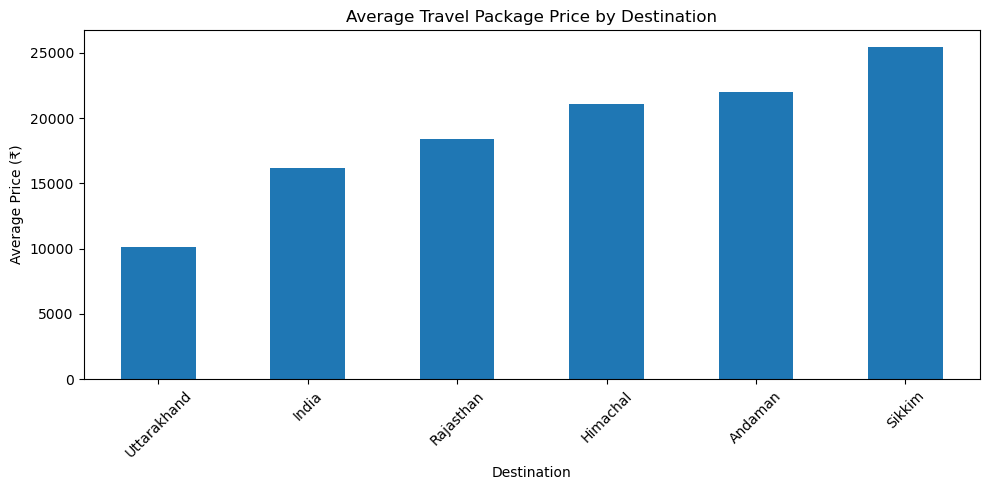

In [46]:
import matplotlib.pyplot as plt

# Average package price by destination
avg_price = df_all.groupby("Destination")["Price_Numeric"].mean().sort_values()

plt.figure(figsize=(10, 5))
avg_price.plot(kind="bar")
plt.title("Average Travel Package Price by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

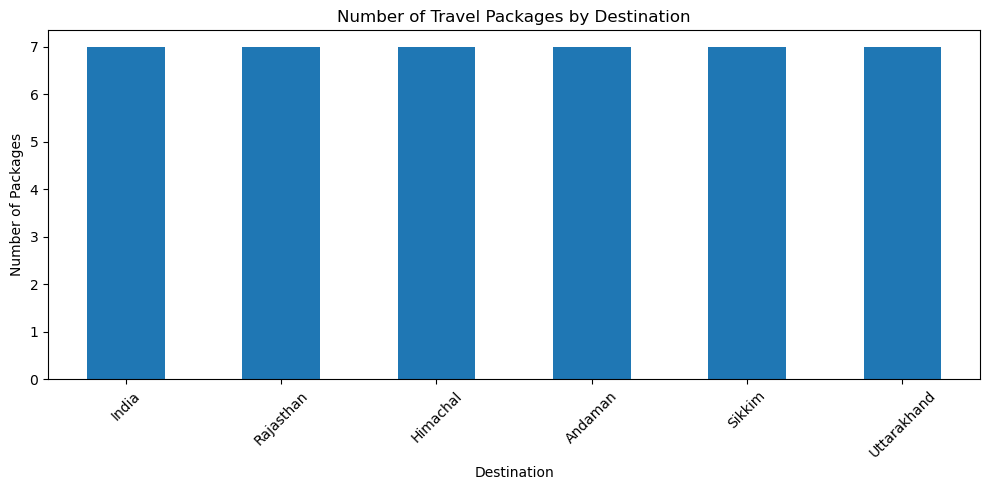

In [47]:
package_count = df_all["Destination"].value_counts()

plt.figure(figsize=(10, 5))
package_count.plot(kind="bar")
plt.title("Number of Travel Packages by Destination")
plt.xlabel("Destination")
plt.ylabel("Number of Packages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

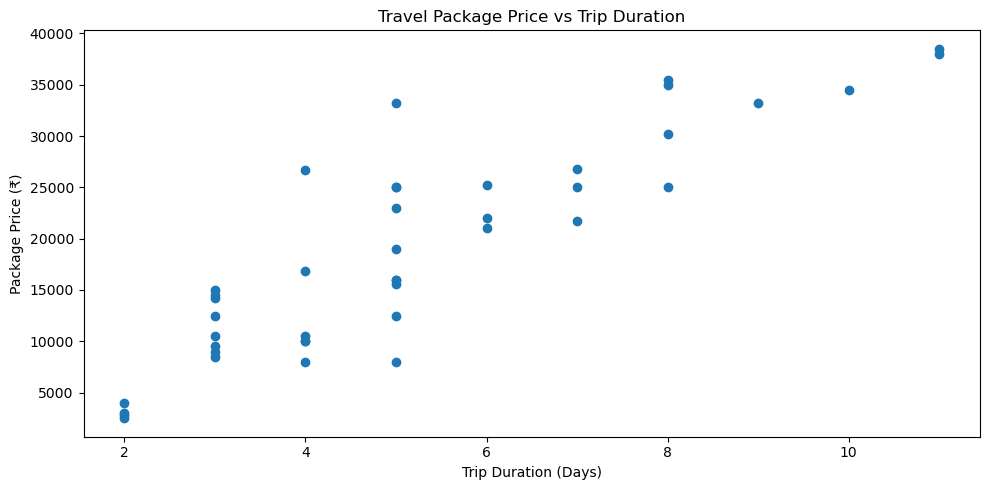

In [48]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_all["Days"],
    df_all["Price_Numeric"]
)

plt.title("Travel Package Price vs Trip Duration")
plt.xlabel("Trip Duration (Days)")
plt.ylabel("Package Price (₹)")
plt.tight_layout()
plt.show()

In [49]:
df_all.to_csv(
    "traveltriangle_final_dataset.csv",
    index=False
)

print("Final dataset saved successfully!")
print("Total records:", len(df_all))

Final dataset saved successfully!
Total records: 42


In [50]:
# Clean column names
df_all.columns = df_all.columns.str.strip()

# Remove any completely empty rows
df_all = df_all.dropna(how="all")

# Save CSV in standard UTF-8 format
df_all.to_csv(
    "traveltriangle_final_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV created successfully!")
print("Rows:", len(df_all))
print("Columns:", len(df_all.columns))
print(df_all.columns.tolist())

CSV created successfully!
Rows: 42
Columns: 9
['Destination', 'Package_Name', 'Duration', 'Price', 'Inclusions', 'URL', 'Price_Numeric', 'Nights', 'Days']


In [51]:
# STEP 15: Business Insights

print("===== BUSINESS INSIGHTS =====")

# 1. Highest average price destination
avg_destination_price = (
    df_all.groupby("Destination")["Price_Numeric"]
    .mean()
    .sort_values(ascending=False)
)

print("\nHighest Average Price Destination:")
print(avg_destination_price.head(1))

# 2. Lowest average price destination
print("\nLowest Average Price Destination:")
print(avg_destination_price.tail(1))

# 3. Most packages
package_counts = df_all["Destination"].value_counts()

print("\nMost Packages:")
print(package_counts.head(1))

# 4. Overall average price
print("\nOverall Average Package Price:")
print(round(df_all["Price_Numeric"].mean(), 2))

# 5. Average duration
print("\nAverage Trip Duration:")
print(round(df_all["Days"].mean(), 2), "days")

===== BUSINESS INSIGHTS =====

Highest Average Price Destination:
Destination
Sikkim    25461.571429
Name: Price_Numeric, dtype: float64

Lowest Average Price Destination:
Destination
Uttarakhand    10103.571429
Name: Price_Numeric, dtype: float64

Most Packages:
Destination
India    7
Name: count, dtype: int64

Overall Average Package Price:
18877.95

Average Trip Duration:
5.19 days


In [52]:
# Price vs Duration correlation

correlation = df_all["Price_Numeric"].corr(df_all["Days"])

print("Price-Duration Correlation:", round(correlation, 2))

Price-Duration Correlation: 0.88


In [53]:
# Final Business Insights

avg_price = df_all.groupby("Destination")["Price_Numeric"].mean().sort_values(ascending=False)
package_count = df_all["Destination"].value_counts()

correlation = df_all["Price_Numeric"].corr(df_all["Days"])

print("1. Highest-price destination:")
print(avg_price.index[0], "→ ₹", round(avg_price.iloc[0], 2))

print("\n2. Lowest-price destination:")
print(avg_price.index[-1], "→ ₹", round(avg_price.iloc[-1], 2))

print("\n3. Destination with most packages:")
print(package_count.index[0], "→", package_count.iloc[0], "packages")

print("\n4. Overall average package price:")
print("₹", round(df_all["Price_Numeric"].mean(), 2))

print("\n5. Price-Duration correlation:")
print(round(correlation, 2))

1. Highest-price destination:
Sikkim → ₹ 25461.57

2. Lowest-price destination:
Uttarakhand → ₹ 10103.57

3. Destination with most packages:
India → 7 packages

4. Overall average package price:
₹ 18877.95

5. Price-Duration correlation:
0.88


### 🔍 Key Business Insights

1. Destination Pricing
Sikkim has the highest average package price, indicating a relatively premium travel offering.

2. Affordable Destination
Uttarakhand has the lowest average package price, making it potentially attractive to budget-conscious travelers.

3. Package Availability
India has the highest number of packages in the scraped dataset, indicating strong package availability.

4. Overall Pricing
The average travel package price across the dataset is ₹18877.95
.
5. Duration & Price
The correlation between trip duration and package price is 0.88, indicating a strong relationship..